In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import joblib
from tensorflow.keras.models import load_model
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models, backend
from pydub import AudioSegment
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Cutting Audios Based on The Metadata

df = pd.read_csv('WCMED-Metadata/WCMED_ Metadata.csv')
output_dir = "audios"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for i, row in df.iterrows():
    audio = AudioSegment.from_file(f"./CPTR330FinalProjAudios/CPTR330FinalProj/{row['songName']}.mp3")
    start_ms = row['start_point'] * 1000
    end_ms = row['stop_point'] * 1000
    segment = audio[start_ms:end_ms]
    output_path = os.path.join(output_dir, row["fileName"])    
    segment.export(output_path, format="mp3")
    print(f"Creat {row['fileName']}")

NameError: name 'os' is not defined

In [2]:
def create_dataset(csv_path, audio_folder, n_mfcc=40, max_pad_len=173):
    df = pd.read_csv(csv_path)
    y_values = (df["rating"].values + 1) / 2 # Normalizing
    
    X = []
    valid_y = []
    for idx, row in df.iterrows():
        file_path = Path(audio_folder) / row['name']
        if file_path.exists():
            try:
                audio, sr = librosa.load(file_path, duration=30)
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
                rms = librosa.feature.rms(y=audio) # Volume
                feat = np.concatenate((mfcc, rms), axis=0)  
                feat = feat.T
                
                # Padding
                if feat.shape[0] < max_pad_len:
                    pad_width = max_pad_len - feat.shape[0]
                    feat = np.pad(feat, pad_width=((0, pad_width), (0, 0)), mode='constant')
                else:
                    feat = feat[:max_pad_len, :]
                    
                feat = feat[..., np.newaxis]
                
                X.append(feat)
                valid_y.append(y_values[idx])
                
            except Exception as e:
                print(f"Error file {file_path}: {e}")
        else:
            print(f"{file_path} not found.")

    return np.array(X), np.array(valid_y)

X_arousal, y_arousal = create_dataset("./WCMED-Ratings/WCMED_Arousal_Rating.csv", "./audios/")
X_valence, y_valence = create_dataset("./WCMED-Ratings/WCMED_Valence_Rating.csv", "./audios/")

C:\Users\radio\miniconda3\envs\CPTR330NLPFinalProj\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


audios\Chopin_Op031_103_20040204-SMD_10.mp3 not found.
audios\Chopin_Op031_103_20040204-SMD_10.mp3 not found.


In [3]:
X_arousal_train, X_arousal_test, y_arousal_train, y_arousal_test = train_test_split(X_arousal, y_arousal, test_size=0.2, random_state=42)
X_valence_train, X_valence_test, y_valence_train, y_valence_test = train_test_split(X_valence, y_valence, test_size=0.2, random_state=42)

In [4]:
input_shape_arousal = (X_arousal.shape[1], X_arousal.shape[2], 1)
input_shape_valence = (X_valence.shape[1], X_valence.shape[2], 1)

In [5]:
class SequentialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(SequentialAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', 
                                 shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(name='att_bias', 
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super(SequentialAttention, self).build(input_shape)

    def call(self, x):
        e = backend.tanh(backend.dot(x, self.W) + self.b) # Aligmenet
        e = backend.squeeze(e, axis=-1) 
        alpha = backend.softmax(e) # logit
        alpha = backend.expand_dims(alpha, axis=-1)        
        return backend.sum(x * alpha, axis=1) # (batch, features)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

In [6]:
model_arousal = models.Sequential([
    layers.Input(shape=input_shape_arousal),
    layers.Reshape((input_shape_arousal[0], input_shape_arousal[1])), # (173, 40)
    # Feature Extraction
    layers.TimeDistributed(layers.Dense(64, activation='relu')),
    layers.BatchNormalization(),  
    # Temporal Modeling
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2)), 
    # Temporal Attention
    SequentialAttention(),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model_valence = models.Sequential([
    layers.Input(shape=input_shape_arousal),
    layers.Reshape((input_shape_arousal[0], input_shape_arousal[1])), # (173, 40)
    # Feature Extraction
    layers.TimeDistributed(layers.Dense(64, activation='relu')),
    layers.BatchNormalization(),  
    # Temporal Modeling
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2)),  
    # Temporal Attention
    SequentialAttention(),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

In [7]:
model_arousal.compile(optimizer='adam', loss='mse', metrics=['mae','mse'])
model_valence.compile(optimizer='adam', loss='mse', metrics=['mae','mse'])

model_arousal.summary()
model_valence.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 173, 41)           0         
                                                                 
 time_distributed (TimeDistr  (None, 173, 64)          2688      
 ibuted)                                                         
                                                                 
 batch_normalization (BatchN  (None, 173, 64)          256       
 ormalization)                                                   
                                                                 
 bidirectional (Bidirectiona  (None, 173, 128)         66048     
 l)                                                              
                                                                 
 sequential_attention (Seque  (None, 128)              301       
 ntialAttention)                                        

In [9]:
history_arousal = model_arousal.fit(X_arousal_train, y_arousal_train, epochs=80, validation_data = (X_arousal_test, y_arousal_test))

Epoch 1/80
10/10 [==============================] - 13s 182ms/step - loss: 0.0501 - mae: 0.1794 - mse: 0.0501 - val_loss: 0.1828 - val_mae: 0.3369 - val_mse: 0.1828
Epoch 2/80
10/10 [==============================] - 1s 57ms/step - loss: 0.0391 - mae: 0.1511 - mse: 0.0391 - val_loss: 0.1653 - val_mae: 0.3233 - val_mse: 0.1653
Epoch 3/80
10/10 [==============================] - 1s 56ms/step - loss: 0.0331 - mae: 0.1426 - mse: 0.0331 - val_loss: 0.1168 - val_mae: 0.2678 - val_mse: 0.1168
Epoch 4/80
10/10 [==============================] - 1s 58ms/step - loss: 0.0315 - mae: 0.1364 - mse: 0.0315 - val_loss: 0.1389 - val_mae: 0.2964 - val_mse: 0.1389
Epoch 5/80
10/10 [==============================] - 1s 57ms/step - loss: 0.0290 - mae: 0.1338 - mse: 0.0290 - val_loss: 0.0915 - val_mae: 0.2357 - val_mse: 0.0915
Epoch 6/80
10/10 [==============================] - 1s 55ms/step - loss: 0.0279 - mae: 0.1281 - mse: 0.0279 - val_loss: 0.0857 - val_mae: 0.2287 - val_mse: 0.0857
Epoch 7/80
10/10 [==

In [10]:
history_valence = model_valence.fit(X_valence_train, y_valence_train, epochs=80, validation_data = (X_valence_test, y_valence_test))

Epoch 1/80
10/10 [==============================] - 5s 148ms/step - loss: 0.0787 - mae: 0.2396 - mse: 0.0787 - val_loss: 0.1093 - val_mae: 0.2780 - val_mse: 0.1093
Epoch 2/80
10/10 [==============================] - 0s 49ms/step - loss: 0.0720 - mae: 0.2269 - mse: 0.0720 - val_loss: 0.0988 - val_mae: 0.2671 - val_mse: 0.0988
Epoch 3/80
10/10 [==============================] - 1s 57ms/step - loss: 0.0688 - mae: 0.2193 - mse: 0.0688 - val_loss: 0.1043 - val_mae: 0.2723 - val_mse: 0.1043
Epoch 4/80
10/10 [==============================] - 1s 54ms/step - loss: 0.0669 - mae: 0.2180 - mse: 0.0669 - val_loss: 0.1031 - val_mae: 0.2698 - val_mse: 0.1031
Epoch 5/80
10/10 [==============================] - 1s 55ms/step - loss: 0.0617 - mae: 0.2106 - mse: 0.0617 - val_loss: 0.1010 - val_mae: 0.2700 - val_mse: 0.1010
Epoch 6/80
10/10 [==============================] - 1s 51ms/step - loss: 0.0575 - mae: 0.1995 - mse: 0.0575 - val_loss: 0.1000 - val_mae: 0.2685 - val_mse: 0.1000
Epoch 7/80
10/10 [===

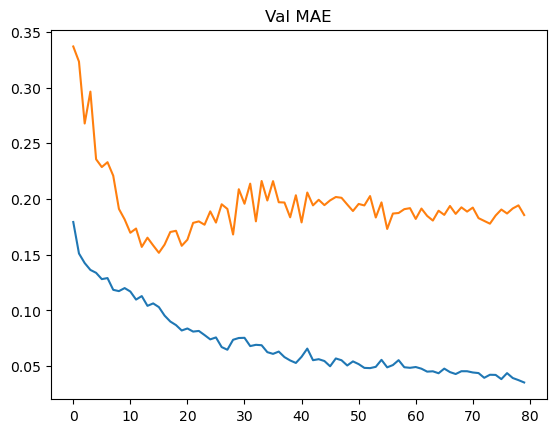

In [11]:
plt.plot(history_arousal.history['mae'])
plt.plot(history_arousal.history['val_mae'])
plt.title('Val MAE')

plt.show()

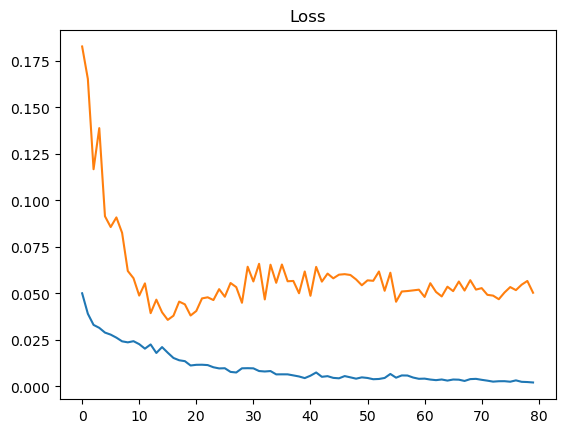

In [12]:
plt.plot(history_arousal.history['loss'])
plt.plot(history_arousal.history['val_loss'])
plt.title('Loss')

plt.show()

13/13 [==============================] - 0s 27ms/step


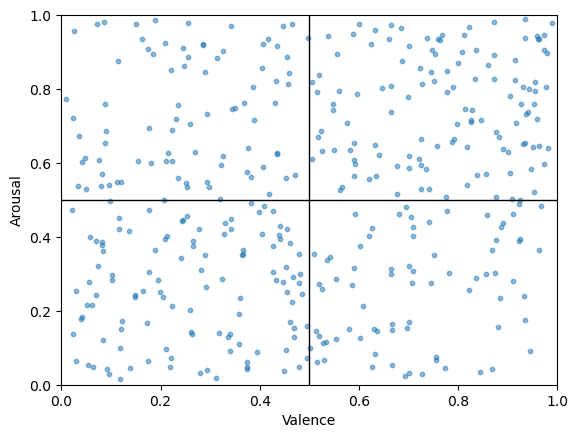

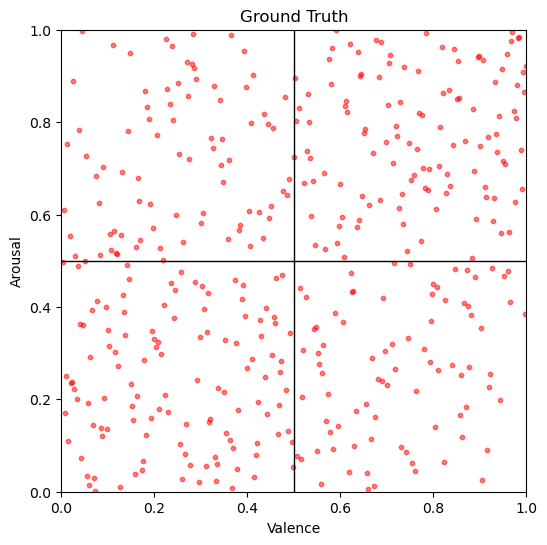

In [17]:
def plot_inference(m_v, m_a, X_v, X_a):
    v_preds = m_v.predict(X_v).flatten()
    a_preds = m_a.predict(X_a).flatten()    
    plt.scatter(v_preds, a_preds, alpha=0.5, s=10)
    #Lines
    plt.axhline(0.5, color='k', lw=1)
    plt.axvline(0.5, color='k', lw=1)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Valence"); 
    plt.ylabel("Arousal")
    plt.show()

def plot_ground_truth(y_v, y_a):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_v, y_a, alpha=0.5, s=10, c='red')
    plt.axhline(0.5, color='k', lw=1)
    plt.axvline(0.5, color='k', lw=1)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title("Ground Truth")
    plt.xlabel("Valence")
    plt.ylabel("Arousal")
    plt.show()

# Execution
plot_inference(model_valence, model_arousal, X_valence, X_arousal)
plot_ground_truth(y_valence, y_arousal)